In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [3]:
import pandas as pd
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical


In [5]:
df = pd.read_csv('metadata.csv')
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,5436e3acbae478396759f0d3,ISIC_0000002,mel,histopathology,60.0,female,upper extremity
1,5436e3acbae478396759f0d7,ISIC_0000004,mel,histopathology,80.0,male,posterior torso
2,5436e3adbae478396759f0e9,ISIC_0000013,mel,histopathology,30.0,female,posterior torso
3,5436e3aebae478396759f0fb,ISIC_0000022,mel,histopathology,55.0,female,lower extremity
4,5436e3aebae478396759f103,ISIC_0000026,mel,histopathology,30.0,female,lower extremity


In [6]:
df.isnull().sum()
df = df.dropna(subset=['image_id', 'dx']) 

In [25]:
image_dir = "C:/deepproject/Images"  # Example: "C:/Users/sree/dataset/images"
df['image_path'] = df['image_id'].apply(lambda x: os.path.join(image_dir, x + ".jpg"))


In [26]:
df.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,label
0,5436e3acbae478396759f0d3,ISIC_0000002,mel,histopathology,60.0,female,upper extremity,C:/deepproject/Images\ISIC_0000002.jpg,4
1,5436e3acbae478396759f0d7,ISIC_0000004,mel,histopathology,80.0,male,posterior torso,C:/deepproject/Images\ISIC_0000004.jpg,4
2,5436e3adbae478396759f0e9,ISIC_0000013,mel,histopathology,30.0,female,posterior torso,C:/deepproject/Images\ISIC_0000013.jpg,4
3,5436e3aebae478396759f0fb,ISIC_0000022,mel,histopathology,55.0,female,lower extremity,C:/deepproject/Images\ISIC_0000022.jpg,4
4,5436e3aebae478396759f103,ISIC_0000026,mel,histopathology,30.0,female,lower extremity,C:/deepproject/Images\ISIC_0000026.jpg,4


In [27]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['dx'])
df['label'].value_counts()


label
4    900
0    600
2    600
1    600
5    275
3    126
Name: count, dtype: int64

In [28]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])


In [29]:
import os

image_dir = "C:/deepproject/Images"  # path to your images folder

# create a new column 'image_path' in df
df['image_path'] = df['image_id'].apply(lambda x: os.path.join(image_dir, str(x) + ".jpg"))


In [30]:
print(df[['image_id', 'image_path']].head())


       image_id                              image_path
0  ISIC_0000002  C:/deepproject/Images\ISIC_0000002.jpg
1  ISIC_0000004  C:/deepproject/Images\ISIC_0000004.jpg
2  ISIC_0000013  C:/deepproject/Images\ISIC_0000013.jpg
3  ISIC_0000022  C:/deepproject/Images\ISIC_0000022.jpg
4  ISIC_0000026  C:/deepproject/Images\ISIC_0000026.jpg


In [31]:
import os

# Check how many images exist
missing_files = df[~df['image_path'].apply(os.path.exists)]
print(f"Number of missing images: {len(missing_files)}")

# Optionally, see first few missing
print(missing_files.head())


Number of missing images: 0
Empty DataFrame
Columns: [lesion_id, image_id, dx, dx_type, age, sex, localization, image_path, label]
Index: []


In [32]:
import os

# Step 1 — Folder path (string variable)
image_dir = "C:/deepproject/Images"  # <-- YOUR actual images folder

# Step 2 — Generate full image paths in a new column
df['image_path'] = df['image_id'].apply(lambda x: os.path.join(image_dir, str(x) + ".jpg"))

# Step 3 — Quick check
print(df[['image_id', 'image_path']].head())   # should show full paths
print(os.path.exists(df['image_path'].iloc[0]))  # should be True if file exists


       image_id                              image_path
0  ISIC_0000002  C:/deepproject/Images\ISIC_0000002.jpg
1  ISIC_0000004  C:/deepproject/Images\ISIC_0000004.jpg
2  ISIC_0000013  C:/deepproject/Images\ISIC_0000013.jpg
3  ISIC_0000022  C:/deepproject/Images\ISIC_0000022.jpg
4  ISIC_0000026  C:/deepproject/Images\ISIC_0000026.jpg
True


In [33]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

IMG_SIZE = (128, 128)  

def load_images(dataframe):
    images = []
    labels = []
    for i, row in dataframe.iterrows():
        img_path = row['image_path']
        if os.path.exists(img_path):  
            img = load_img(img_path, target_size=IMG_SIZE)
            img = img_to_array(img) / 255.0  
            images.append(img)
            labels.append(row['label'])
        else:
            print(f"⚠️ Missing file skipped: {img_path}")
    return np.array(images), np.array(labels)


X_train, y_train = load_images(train_df)
X_test, y_test = load_images(test_df)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (2480, 128, 128, 3)
y_train shape: (2480,)
X_test shape: (621, 128, 128, 3)
y_test shape: (621,)


In [34]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("y_train one-hot shape:", y_train.shape)
print("y_test one-hot shape:", y_test.shape)


y_train one-hot shape: (2480, 6)
y_test one-hot shape: (621, 6)


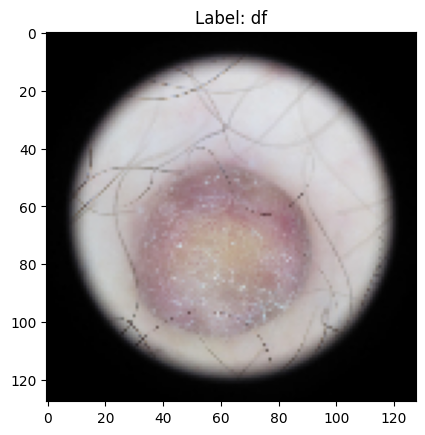

In [35]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0])
plt.title(f"Label: {label_encoder.inverse_transform([np.argmax(y_train[0])])[0]}")
plt.show()


In [36]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [38]:
num_classes = y_train.shape[1]  

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  
])


c:\Users\srees\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # because labels are one-hot encoded
    metrics=['accuracy']
)

model.summary()  # check model layers and parameters


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [41]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,   # 20% of train used as validation
    epochs=25,              # you can increase later
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 0.2954 - loss: 1.6487 - val_accuracy: 0.3387 - val_loss: 1.5500
Epoch 2/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.3821 - loss: 1.5221 - val_accuracy: 0.3851 - val_loss: 1.4948
Epoch 3/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.4083 - loss: 1.4546 - val_accuracy: 0.4214 - val_loss: 1.4415
Epoch 4/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.4471 - loss: 1.3983 - val_accuracy: 0.4657 - val_loss: 1.3873
Epoch 5/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.4642 - loss: 1.3556 - val_accuracy: 0.4617 - val_loss: 1.3672
Epoch 6/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.4879 - loss: 1.2936 - val_accuracy: 0.4496 - val_loss: 1.3674
Epoch 7/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.4975 - loss: 1.2654 - val_accuracy: 0.4798 - val_loss: 1.3981
Epoch 8/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.5338 - loss: 1.2173 - val_accuracy: 

In [54]:
# Save the trained model
model.save("skin_lesion_model.keras")

# Save the label encoder
import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)


In [55]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5169 - loss: 1.2498
Test Accuracy: 51.69%


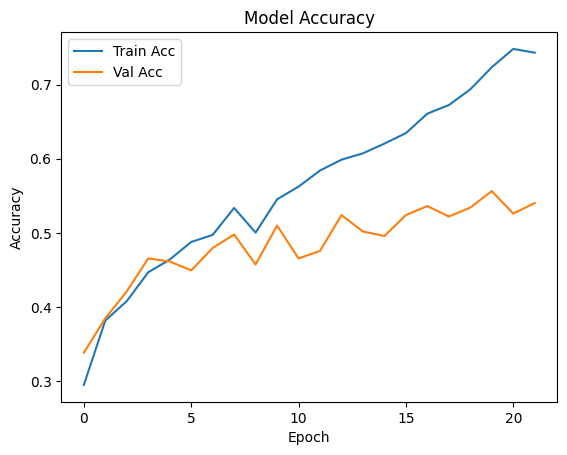

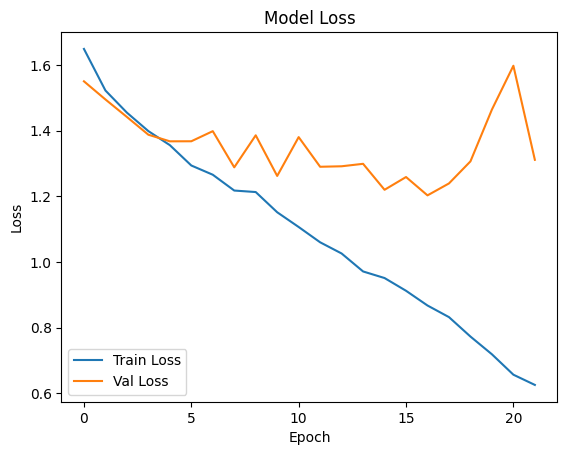

In [56]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [57]:
# Predict probabilities for each class
y_pred_probs = model.predict(X_test)  # shape: (num_test_samples, num_classes)

# Convert probabilities to class indices
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded y_test back to class indices
y_true_classes = np.argmax(y_test, axis=1)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [58]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Test Accuracy: 51.69%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


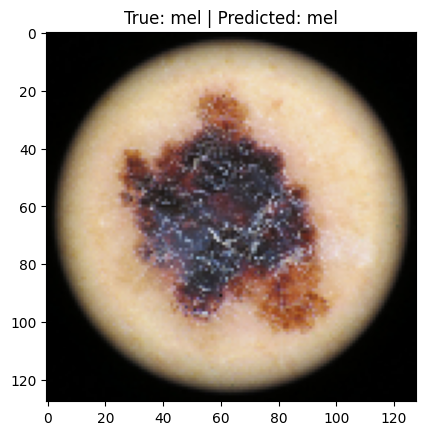

In [59]:
import matplotlib.pyplot as plt

# Pick the first test image
img = X_test[0]
true_label_index = np.argmax(y_test[0])

# Model prediction
pred_probs = model.predict(np.expand_dims(img, axis=0))
pred_label_index = np.argmax(pred_probs)

# Convert indices to actual labels
true_label = label_encoder.inverse_transform([true_label_index])[0]
pred_label = label_encoder.inverse_transform([pred_label_index])[0]

# Show image with prediction
plt.imshow(img)
plt.title(f"True: {true_label} | Predicted: {pred_label}")
plt.show()


In [60]:
import matplotlib.pyplot as plt
import numpy as np

def predict_test_image(index):
    """
    Predict and display a test image from X_test.

    Parameters:
    index: int, index of the image in X_test/test_df
    """
    # Get the image and true label
    img = X_test[index]
    true_label_index = np.argmax(y_test[index])
    
    # Predict
    pred_probs = model.predict(np.expand_dims(img, axis=0))
    pred_label_index = np.argmax(pred_probs)
    
    # Convert indices to original labels
    true_label = label_encoder.inverse_transform([true_label_index])[0]
    pred_label = label_encoder.inverse_transform([pred_label_index])[0]
    
    # Display image with prediction
    plt.imshow(img)
    plt.title(f"True: {true_label} | Predicted: {pred_label}")
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


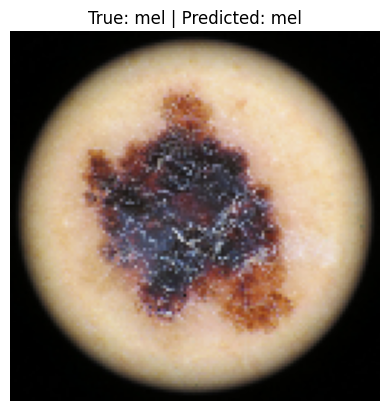

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


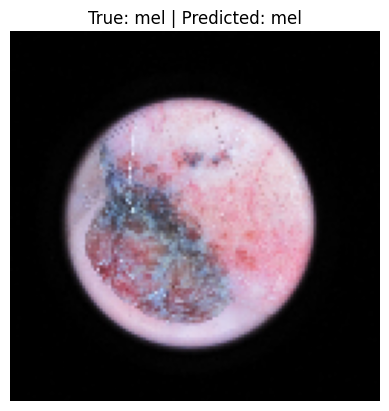

In [61]:
predict_test_image(0)  # show the first test image
predict_test_image(5)  # show the 6th test image


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


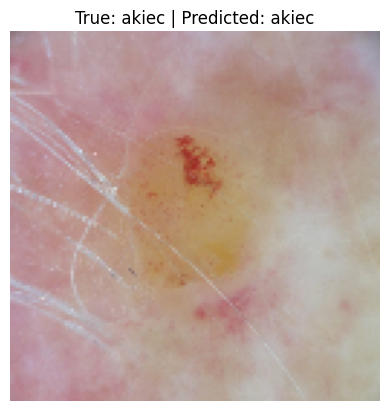

In [62]:
predict_test_image(10)

In [63]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = (128, 128)  # same as used in training
image_path = "C:/deepproject/Images/mel test.jpeg"  # replace with your image path

# Load image
img = load_img(image_path, target_size=IMG_SIZE)

# Convert to array and normalize
img_array = img_to_array(img) / 255.0

# Expand dimensions to make it (1, 128, 128, 3)
img_array = np.expand_dims(img_array, axis=0)


In [64]:
# Predict probabilities
pred_probs = model.predict(img_array)

# Get the index of the class with highest probability
pred_index = np.argmax(pred_probs)

# Convert index to actual label
pred_label = label_encoder.inverse_transform([pred_index])[0]

print(f"Predicted Label: {pred_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Label: mel


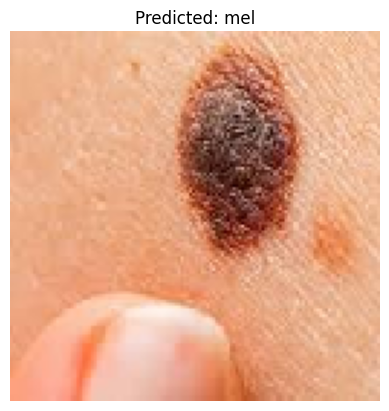

In [65]:
plt.imshow(img)
plt.title(f"Predicted: {pred_label}")
plt.axis('off')
plt.show()


In [3]:
from tensorflow.keras.models import load_model
import pickle

# Load the trained model
model = load_model("skin_lesion_model.keras")

# Load the label encoder
with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

# Make sure IMG_SIZE matches training
IMG_SIZE = (128, 128)


In [4]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import os

def predict_new_image(image_path):
    """
    Predict the class of a new image and display it.
    
    Parameters:
    image_path: str, path to the image file
    """
    if not os.path.exists(image_path):
        print("❌ Image not found!")
        return

    # Load and preprocess
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # shape (1, 128, 128, 3)

    # Predict
    pred_probs = model.predict(img_array)
    pred_index = np.argmax(pred_probs)
    pred_label = label_encoder.inverse_transform([pred_index])[0]

    # Show image with prediction
    plt.imshow(img)
    plt.title(f"Predicted: {pred_label}")
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\srees\AppData\Local\Temp\ipykernel_9732\3987826718.py:1: SyntaxWarning: invalid escape sequence '\d'
  predict_new_image("C:\deepproject\Images\mel test.jpeg")  # replace with your image path


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


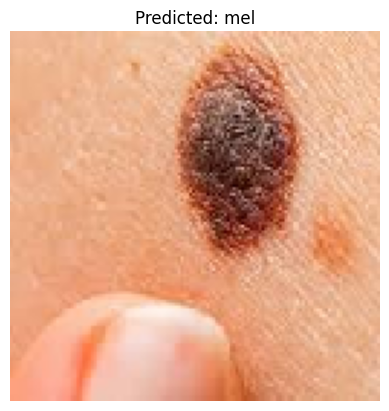

In [5]:
predict_new_image("C:\deepproject\Images\mel test.jpeg")  # replace with your image path


In [6]:
predict_new_image("https://www.researchgate.net/publication/369905149/figure/fig2/AS:11431281141811923@1681089724409/Sample-skin-lesion-images-from-the-dataset-a-AKIEC-b-BCC-c-BKL-d-DF-e-MEL_Q320.jpg")

❌ Image not found!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


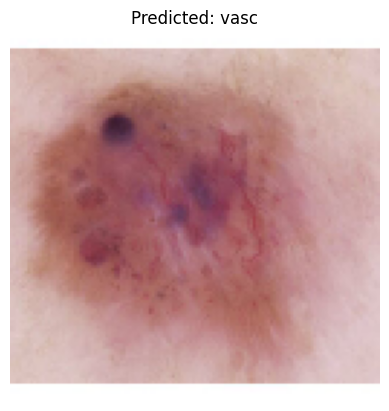

In [7]:
predict_new_image("C:\\deepproject\\Images\\test1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


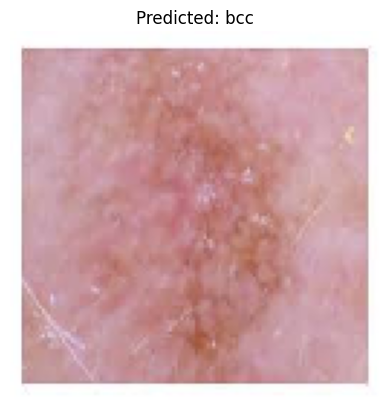

In [8]:
predict_new_image("C:\\deepproject\\Images\\test2.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


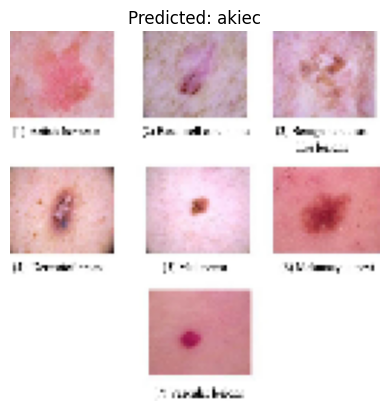

In [9]:
predict_new_image("C:\\deepproject\\Images\\test3.jpg")